# **A05 - Pipeline**

---
Nombre: **Alan Jesús Hernández Soto** \
Carrera: **Ingeniería Financiera** \
Materia: **Laboratorio de Aprendizaje Estadístico** \
Tipo de Trabajo: **Actividad**

---

## Índice

1. Tratamiento de datos
2. Pipeline y regresión lineal
3. Análisis de residuos
4. Validación cruzada

## 1. Tratamiento de datos

**Importación de librerías**

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Carga y exploración inicial**

In [130]:
df = pd.read_excel('Datasets/Motor Trend Car Road Tests.xlsx')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   model   32 non-null     object 
 1   mpg     32 non-null     float64
 2   cyl     32 non-null     int64  
 3   disp    32 non-null     float64
 4   hp      32 non-null     int64  
 5   drat    32 non-null     float64
 6   wt      32 non-null     float64
 7   qsec    32 non-null     float64
 8   vs      32 non-null     int64  
 9   am      32 non-null     int64  
 10  gear    32 non-null     int64  
 11  carb    32 non-null     int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 3.1+ KB


**Definición y clasificación de variables**

| Variable | Definición breve | Tipo |
| --- | --- | --- |
| `model` | Nombre o identificador del automóvil. | Categórica nominal |
| `mpg` | Rendimiento de combustible en millas por galón estadounidense. | Numérica continua; variable objetivo |
| `cyl` | Número de cilindros del motor. | Categórica ordinal |
| `disp` | Cilindrada del motor, en pulgadas cúbicas. | Numérica continua |
| `hp` | Potencia bruta, en caballos de fuerza. | Numérica discreta |
| `drat` | Relación del eje trasero. | Numérica continua |
| `wt` | Peso del automóvil, en miles de libras. | Numérica continua |
| `qsec` | Tiempo para recorrer un cuarto de milla, en segundos. | Numérica continua |
| `vs` | Configuración del motor: 0 = V, 1 = en línea. | Booleana |
| `am` | Transmisión: 0 = automática, 1 = manual. | Booleana |
| `gear` | Número de marchas hacia adelante. | Numérica discreta |
| `carb` | Número de carburadores. | Numérica discreta |

**Eliminación del identificador**

In [131]:
df = df.drop(columns=['model'])

In [132]:
display(df)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


**Selección de variable objetivo y grupos de predictores**

In [133]:
target_col = 'mpg'
categorical_cols = ['cyl']
boolean_cols = ['vs', 'am']
numerical_cols = df[df.columns.difference(categorical_cols + boolean_cols + [target_col])].columns.tolist()

## 2. Pipeline y regresión lineal

**Construcción y ajuste del pipeline**

In [134]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols),
        ('bool', 'passthrough', bool_cols)
    ], remainder='drop')

model = LinearRegression()
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ]
)

X = df.drop(columns=[target_col])
Y = df[target_col]
pipeline.fit(X, Y)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

**Parámetros y desempeño en entrenamiento**

In [135]:
pipeline['model'].intercept_, pipeline['model'].coef_

(np.float64(17.9020690159769),
 array([ 0.80974724,  1.6971302 ,  0.01386703,  0.55482605, -3.112883  ,
         1.13786856, -3.66559798,  0.00762231, -1.65268442,  1.64506211,
         1.74738689,  2.61726546]))

In [136]:
pipeline.score(X, Y)

0.8816004757083714

## 3. Análisis de residuos

In [137]:
y_pred = pipeline.predict(X)
E = Y - y_pred

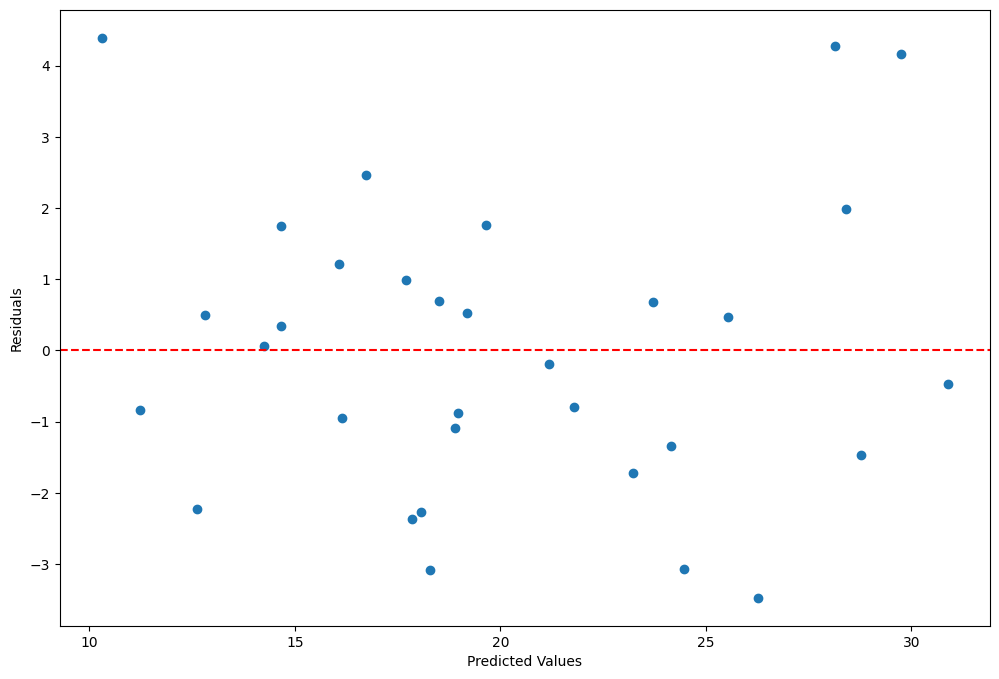

In [138]:
plt.figure(figsize=(12, 8))
plt.scatter(y_pred, E)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

## 4. Validación cruzada

In [139]:
from sklearn.model_selection import cross_val_score
mean_cv = cross_val_score(pipeline, X, Y, cv=32, scoring='neg_mean_squared_error').mean()
std_cv = cross_val_score(pipeline, X, Y, cv=32, scoring='neg_mean_squared_error').std()
print(f'Promedio CV Score: {mean_cv}, Desviacion Estandar CV Score: {std_cv}')


Promedio CV Score: -10.629696260618056, Desviacion Estandar CV Score: 13.699356445983911
